In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import cross_validate, KFold

In [3]:
DATA_DIR = Path.cwd().parent / 'datasets' / 'processed'
MODELS_DIR = Path.cwd().parent / 'models'

data = pd.read_csv(DATA_DIR / 'final_train.csv')
X_train = data.drop('SalePrice', axis=1)
y_train = data['SalePrice']

# MODELS_DIR.glob('*_model.pkl') <> returns all files that ends with _model.pkl
model_files = list( MODELS_DIR.glob('*_model.pkl'))

# f.stem <> returns name of file without extension
loaded_models = {f.stem.replace('_model', ''): joblib.load(f) for f in model_files}

print(f"Loaded {len(loaded_models)} models: {list(loaded_models.keys())}")

Loaded 7 models: ['Cat_Boost_Regressor', 'Gradient_Boosting_Regressor', 'LGBM_Regressor', 'Linear_Regression', 'Random_Forest_Regressor', 'ridge', 'XGB_Regressor']


In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for model_name , model in loaded_models.items(): 
    cv_results = cross_validate(  model , X_train, y_train, cv=cv,
                                   scoring='neg_root_mean_squared_error'
                                   )
    
    results[model_name] = -cv_results['test_score'].mean()
    print(f"Evaluated: {model_name}")

Evaluated: Cat_Boost_Regressor
Evaluated: Gradient_Boosting_Regressor
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001708 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4707
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 208
[LightGBM] [Info] Start training from score 12.023362
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [5]:
results_df = pd.DataFrame(
    list(results.items()), columns=['Model', 'Test_RMSE']
 ).sort_values(by='Test_RMSE', ascending=True).reset_index(drop=True)

results_df

,Model,Test_RMSE
0,Cat_Boost_Regressor,0.111179
1,Gradient_Boosting_Regressor,0.112465
2,ridge,0.113741
3,XGB_Regressor,0.117449
4,Linear_Regression,0.118675
5,LGBM_Regressor,0.119206
6,Random_Forest_Regressor,0.131160


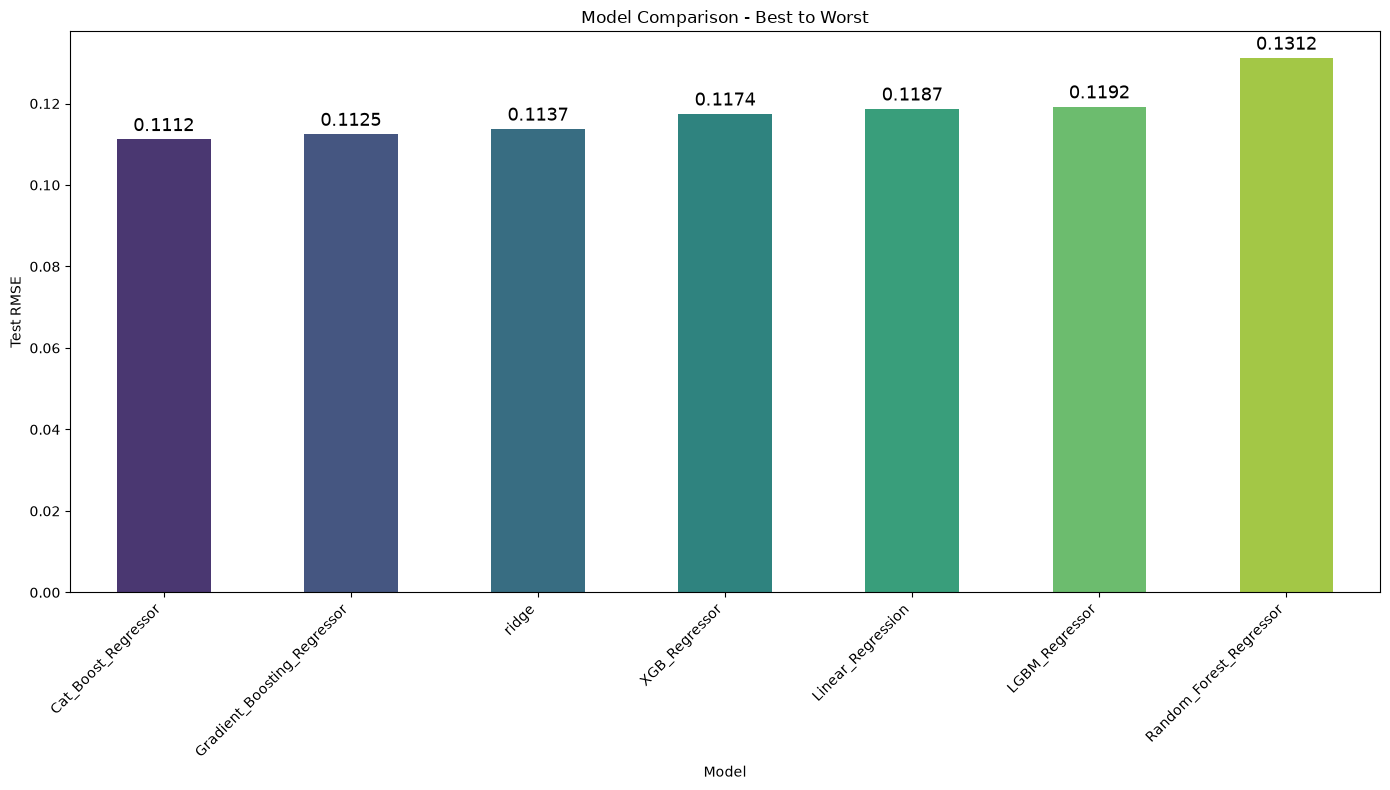

Best model: Cat_Boost_Regressor


In [6]:
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    x=results_df['Model'], y=results_df['Test_RMSE'],
    palette='viridis', hue=results_df['Model'], legend=False, width=0.5
                )

for i, v in enumerate(results_df['Test_RMSE']):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=13)

plt.xlabel('Model')
plt.ylabel('Test RMSE')
plt.title('Model Comparison - Best to Worst')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Best model: {results_df.iloc[0]['Model']}")

In [7]:
results_df.to_csv(DATA_DIR / 'model_evaluation_results.csv', index=False)